# Mamba State-Space Crypto Direction Prediction

Pure-PyTorch Selective SSM (Mamba, Gu & Dao 2023) pour la prediction de direction
crypto (BTC-USD, ETH-USD). Comparaison a DLinear et TFT (resultats #944).

**Architecture Mamba** : selective scan avec input-dependent discretization,
sans custom CUDA kernels (pure PyTorch, CPU-compatible).

**Approche** :
- Donnees : BTC-USD + ETH-USD (yfinance, 2018-2024)
- Features : log-returns, RSI(14), MACD signal, Bollinger position, lagged 1-5
- Modeles : Mamba (selective SSM), DLinear, TFT (lite)
- Validation : Walk-forward 5-fold x 4 seeds (0, 7, 42, 99)
- Couts : 10bps par changement de position
- CPU-only (po-2025 contrainte thermique)

**Verdict honnete** : BEATS / NO BEATS / INCONCLUSIVE (edge >= 2sigma cross-seed)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

SEEDS = [0, 7, 42, 99]
N_FOLDS = 5
TCOST_BPS = 10
SEQUENCE_LENGTH = 21
TICKERS = ['BTC-USD', 'ETH-USD']
DEVICE = torch.device('cpu')

np.random.seed(42)
torch.manual_seed(42)
print(f'PyTorch {torch.__version__}')
print(f'Device: {DEVICE}')
print(f'Tickers: {TICKERS}')
print(f'Seeds: {SEEDS}, Folds: {N_FOLDS}, SeqLen: {SEQUENCE_LENGTH}')

PyTorch 2.11.0+cpu
Device: cpu
Tickers: ['BTC-USD', 'ETH-USD']
Seeds: [0, 7, 42, 99], Folds: 5, SeqLen: 21


## 1. Telechargement et Feature Engineering

Donnees quotidiennes BTC-USD + ETH-USD (2018-2024).
Features : log-returns, RSI(14), MACD signal, Bollinger position, lagged returns 1-5.

In [2]:
# Telechargement
print('Telechargement des donnees...')
raw = yf.download(TICKERS, start='2017-01-01', end='2025-01-01', auto_adjust=True)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'].copy()
else:
    prices = raw[['Close']].copy()

prices = prices.dropna()
print(f'Periode: {prices.index[0].date()} a {prices.index[-1].date()}')
print(f'Jours: {len(prices)}')
print(f'Prix recents:')
for t in prices.columns:
    print(f'  {t}: ${float(prices[t].iloc[-1]):,.2f}')

Telechargement des donnees...


[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

Periode: 2017-11-09 a 2024-12-31
Jours: 2610
Prix recents:
  BTC-USD: $93,429.20
  ETH-USD: $3,332.53


In [3]:
def compute_features(close_prices):
    """Compute features from close prices."""
    c = close_prices.values.ravel()

    # Log returns (index shifted by 1 for diff)
    log_ret = np.log(c[1:] / c[:-1])
    df = pd.DataFrame({'log_ret': log_ret}, index=close_prices.index[1:])

    # RSI(14)
    delta = df['log_ret'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    df['rsi14'] = 100 - (100 / (1 + rs))

    # MACD signal
    ema12 = df['log_ret'].ewm(span=12).mean()
    ema26 = df['log_ret'].ewm(span=26).mean()
    df['macd_signal'] = (ema12 - ema26).ewm(span=9).mean()

    # Bollinger position
    sma20 = df['log_ret'].rolling(20).mean()
    std20 = df['log_ret'].rolling(20).std()
    df['boll_pos'] = (df['log_ret'] - sma20) / (std20 + 1e-10)

    # Lagged returns
    for lag in range(1, 6):
        df[f'lag_{lag}'] = df['log_ret'].shift(lag)

    # Target: direction of next day
    df['target'] = (df['log_ret'].shift(-1) > 0).astype(int)

    df = df.dropna()
    return df


# Build features per ticker then combine
all_dfs = []
for ticker in prices.columns:
    feat_df = compute_features(prices[[ticker]])
    feat_df['ticker'] = ticker
    all_dfs.append(feat_df)

data = pd.concat(all_dfs, axis=0).sort_index()
feature_cols = ['log_ret', 'rsi14', 'macd_signal', 'boll_pos',
                'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']

X_all = data[feature_cols].values.astype(np.float32)
y_all = data['target'].values.astype(np.int64)
dates_all = data.index
tickers_all = data['ticker'].values

print(f'Features: {X_all.shape}')
print(f'Feature cols: {feature_cols}')
print(f'Target balance: {y_all.mean():.3f} (hausse)')
print(f'Samples: {len(X_all)}')

Features: (5180, 9)
Feature cols: ['log_ret', 'rsi14', 'macd_signal', 'boll_pos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']
Target balance: 0.513 (hausse)
Samples: 5180


## 2. Modeles

### 2a. Selective SSM (Mamba) — Pure PyTorch

Implementation sans custom CUDA kernels :
- Discretisation input-dependente (A, B, C, Delta sont fonctions de x)
- Selective scan en Python pur (pas de parallelisme CUDA mais correct)
- Architecture : input -> 2 layers Mamba -> linear head

In [4]:
class SelectiveSSMBlock(nn.Module):
    """Single selective state-space model block (Mamba-style, pure PyTorch)."""

    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = int(expand * d_model)

        # Input projection
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)

        # Conv for local context
        self.conv1d = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner
        )

        # SSM parameters (input-dependent)
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        # A parameter (diagonal, log space for stability)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(self.d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))

        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        Returns: (batch, seq_len, d_model)
        """
        B_sz, L, _ = x.shape
        residual = x
        x = self.norm(x)

        xz = self.in_proj(x)  # (B, L, 2*d_inner)
        x_proj, z = xz.chunk(2, dim=-1)  # each (B, L, d_inner)

        # Conv for local context
        x_conv = x_proj.transpose(1, 2)  # (B, d_inner, L)
        x_conv = self.conv1d(x_conv)[:, :, :L].transpose(1, 2)  # (B, L, d_inner)
        x_conv = F.silu(x_conv)

        # SSM parameters from input
        ssm_params = self.x_proj(x_conv)  # (B, L, d_state*2+1)
        B_ssm = ssm_params[:, :, :self.d_state]  # (B, L, d_state)
        C_ssm = ssm_params[:, :, self.d_state:self.d_state*2]  # (B, L, d_state)
        dt = F.softplus(ssm_params[:, :, -1:])  # (B, L, 1)
        dt = self.dt_proj(dt)  # (B, L, d_inner)

        A = -torch.exp(self.A_log)  # (d_inner, d_state)

        # Selective scan (sequential, CPU-safe)
        y = self._selective_scan(x_conv, dt, A, B_ssm, C_ssm)
        y = y + x_conv * self.D  # skip connection with D

        # Gate
        y = y * F.silu(z)
        output = self.out_proj(y)
        return output + residual

    def _selective_scan(self, x, dt, A, B, C):
        """Selective scan: sequential state update (pure PyTorch)."""
        B_sz, L, D = x.shape
        N = self.d_state

        # Discretize A and B
        dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))  # (B, L, D, N)
        dB = dt.unsqueeze(-1) * B.unsqueeze(2)  # (B, L, D, N)

        # Sequential scan
        h = torch.zeros(B_sz, D, N, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            h = h * dA[:, t] + x[:, t].unsqueeze(-1) * dB[:, t]
            y_t = (h * C[:, t].unsqueeze(1)).sum(-1)  # (B, D)
            ys.append(y_t)
        return torch.stack(ys, dim=1)  # (B, L, D)


class MambaModel(nn.Module):
    """Mamba-based classifier for direction prediction."""

    def __init__(self, input_dim, d_model=64, d_state=16, n_layers=2, n_classes=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([
            SelectiveSSMBlock(d_model, d_state=d_state)
            for _ in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, x):
        """x: (batch, seq_len, input_dim) -> (batch, seq_len, n_classes)"""
        h = self.input_proj(x)
        for layer in self.layers:
            h = layer(h)
        return self.head(h)

print('Mamba model (pure PyTorch) defined')
print(f'  d_model=64, d_state=16, n_layers=2')

Mamba model (pure PyTorch) defined
  d_model=64, d_state=16, n_layers=2


### 2b. DLinear et TFT Lite

Modeles de comparaison : DLinear (channel-independent linear) et TFT simplifie.

In [5]:
class DLinearModel(nn.Module):
    """DLinear: moving average + linear residual."""

    def __init__(self, seq_len, input_dim, n_classes=2):
        super().__init__()
        self.seq_len = seq_len
        self.linear = nn.Linear(seq_len * input_dim, n_classes)

    def forward(self, x):
        B, L, D = x.shape
        return self.linear(x.reshape(B, -1))


class TFTLiteModel(nn.Module):
    """Simplified TFT: LSTM encoder + attention."""

    def __init__(self, input_dim, d_model=32, n_heads=2, n_classes=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.lstm = nn.LSTM(d_model, d_model, num_layers=1, batch_first=True)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x):
        h = self.input_proj(x)
        h, _ = self.lstm(h)
        h2, _ = self.attn(h, h, h)
        h = h + h2
        return self.head(h[:, -1, :])  # last timestep

print('DLinear + TFT Lite models defined')

DLinear + TFT Lite models defined


## 3. Entrainement et Walk-Forward Validation

Walk-forward 5-fold avec fenetre expansive.
Sequence length = 21 jours, prediction au dernier timestep.
Strategie : predire direction, investir si prob(hausse) > 0.5,
couts de transaction 10bps par changement de position.

In [6]:
def create_sequences(X, y, seq_len):
    """Create overlapping sequences."""
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def train_model(model, X_train, y_train, epochs, batch_size, device, lr=1e-3):
    """Train a model with early stopping."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.LongTensor(y_train).to(device)

    best_loss = float('inf')
    patience = 5
    wait = 0

    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_t))
        total_loss = 0
        n_batches = 0

        for i in range(0, len(X_t), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_X = X_t[batch_idx]
            batch_y = y_t[batch_idx]

            if hasattr(model, 'forward') and 'DLinear' in model.__class__.__name__:
                logits = model(batch_X)  # DLinear uses all timesteps
            elif 'TFTLite' in model.__class__.__name__:
                logits = model(batch_X)  # TFT uses last timestep
            else:
                logits = model(batch_X)[:, -1, :]  # Mamba: last timestep

            loss = criterion(logits, batch_y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return model


def predict_direction(model, X_test, device):
    """Get probability of upward direction."""
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        if 'DLinear' in model.__class__.__name__:
            logits = model(X_t)
        elif 'TFTLite' in model.__class__.__name__:
            logits = model(X_t)
        else:
            logits = model(X_t)[:, -1, :]
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    return probs


def simulate_strategy(pred_probs, actual_returns, tcost_bps=10):
    """Simulate long/flat strategy with transaction costs."""
    tcost = tcost_bps / 10000
    position = 0
    daily_rets = []

    for i in range(len(pred_probs)):
        new_pos = 1 if pred_probs[i] > 0.5 else 0
        cost = abs(new_pos - position) * tcost
        ret = new_pos * actual_returns[i] - cost
        daily_rets.append(ret)
        position = new_pos

    daily_rets = np.array(daily_rets)
    sharpe = np.mean(daily_rets) / (np.std(daily_rets) + 1e-10) * np.sqrt(252)
    cum_ret = np.prod(1 + daily_rets) - 1
    return {'sharpe': sharpe, 'cum_return': cum_ret, 'daily_returns': daily_rets}

print('Training utilities defined')

Training utilities defined


In [7]:
# Build sequences
X_seq, y_seq = create_sequences(X_all, y_all, SEQUENCE_LENGTH)
# Align dates/tickers for the sequences
seq_offset = SEQUENCE_LENGTH
dates_seq = dates_all[seq_offset:]
tickers_seq = tickers_all[seq_offset:]

# Also need raw returns for simulation
raw_returns = {}
for t in prices.columns:
    c = prices[t].values
    raw_returns[t] = np.diff(c) / c[:-1]
returns_dates = prices.index[1:]
returns_series = {t: pd.Series(raw_returns[t], index=returns_dates) for t in raw_returns}

print(f'Sequences: {X_seq.shape}')
print(f'Target: {y_seq.shape}')
print(f'Sequence length: {SEQUENCE_LENGTH}')

Sequences: (5159, 21, 9)
Target: (5159,)
Sequence length: 21


## 4. Walk-Forward Multi-Seed Validation

In [8]:
EPOCHS = 20
BATCH_SIZE = 64
INPUT_DIM = len(feature_cols)

results_all = []
n_total = len(X_seq)
fold_size = n_total // (N_FOLDS + 1)

print('='*60)
print('WALK-FORWARD VALIDATION — Mamba vs DLinear vs TFT Lite')
print('='*60)

for SEED in SEEDS:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    for fold in range(N_FOLDS):
        train_end = fold_size * (fold + 1)
        test_start = train_end
        test_end = min(train_end + fold_size, n_total)

        if test_end <= test_start:
            continue

        X_train, X_test = X_seq[:train_end], X_seq[test_start:test_end]
        y_train, y_test = y_seq[:train_end], y_seq[test_start:test_end]

        # Scale features
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(
            X_train.reshape(-1, INPUT_DIM)).reshape(X_train.shape)
        X_test_s = scaler.transform(
            X_test.reshape(-1, INPUT_DIM)).reshape(X_test.shape)

        fold_results = {'seed': SEED, 'fold': fold}

        for model_name, model_cls, kwargs in [
            ('Mamba', MambaModel,
             {'input_dim': INPUT_DIM, 'd_model': 64, 'd_state': 16, 'n_layers': 2}),
            ('DLinear', DLinearModel,
             {'seq_len': SEQUENCE_LENGTH, 'input_dim': INPUT_DIM}),
            ('TFT-Lite', TFTLiteModel,
             {'input_dim': INPUT_DIM, 'd_model': 32, 'n_heads': 2}),
        ]:
            np.random.seed(SEED)
            torch.manual_seed(SEED)
            model = model_cls(**kwargs)
            model = train_model(model, X_train_s, y_train, EPOCHS, BATCH_SIZE, DEVICE)

            probs = predict_direction(model, X_test_s, DEVICE)

            # Get actual returns for simulation
            test_dates = dates_seq[test_start:test_end]
            test_tickers = tickers_seq[test_start:test_end]
            actual_rets = np.array([
                returns_series[t].get(d, 0.0) if t in returns_series else 0.0
                for t, d in zip(test_tickers, test_dates)
            ])

            trade_result = simulate_strategy(probs, actual_rets, TCOST_BPS)

            results_all.append({
                'seed': SEED, 'fold': fold, 'model': model_name,
                'sharpe': trade_result['sharpe'],
                'cum_return': trade_result['cum_return'],
            })

        # Progress print (last model in loop)
        last = results_all[-1]
        print(f'Seed={SEED} Fold={fold}: ' +
              ', '.join(
                  f"{r['model']} S={r['sharpe']:.2f}"
                  for r in results_all[-3:]
              ))

print(f'\nTotal configs: {len(results_all)}')

WALK-FORWARD VALIDATION — Mamba vs DLinear vs TFT Lite


Seed=0 Fold=0: Mamba S=0.00, DLinear S=-0.42, TFT-Lite S=-0.30


Seed=0 Fold=1: Mamba S=0.00, DLinear S=0.07, TFT-Lite S=1.29


Seed=0 Fold=2: Mamba S=0.00, DLinear S=-0.92, TFT-Lite S=-1.06


Seed=0 Fold=3: Mamba S=0.00, DLinear S=-0.66, TFT-Lite S=-0.26


...

Seed=99 Fold=0: Mamba S=0.00, DLinear S=-0.07, TFT-Lite S=0.04


Seed=99 Fold=1: Mamba S=0.00, DLinear S=0.74, TFT-Lite S=0.95


Seed=99 Fold=2: Mamba S=0.00, DLinear S=-0.31, TFT-Lite S=-0.84


Seed=99 Fold=3: Mamba S=0.00, DLinear S=-0.06, TFT-Lite S=-0.95


Seed=99 Fold=4: Mamba S=0.00, DLinear S=0.31, TFT-Lite S=0.39

Total configs: 60


## 5. Resultats et Verdict Multi-Seed

Agreger walk-forward par seed, comparer 3 baselines.
Verdict : BEATS si edge >= 2sigma cross-seed.

In [9]:
df_results = pd.DataFrame(results_all)

print('='*60)
print('RESULTATS MULTI-SEED — Mamba vs DLinear vs TFT-Lite')
print('='*60)

seed_stats = df_results.groupby(['seed', 'model']).agg({
    'sharpe': 'mean',
    'cum_return': 'mean'
}).round(4)

print('\nSharpe par seed et modele:')
print(seed_stats['sharpe'].unstack().to_string())

# Benchmark: Buy-and-Hold equal-weighted
bh_daily = []
for t in prices.columns:
    bh_daily.append(raw_returns[t])
bh_rets = np.mean(bh_daily, axis=0)
bh_sharpe = np.mean(bh_rets) / (np.std(bh_rets) + 1e-10) * np.sqrt(252)
print(f'\nBenchmark BH Sharpe: {bh_sharpe:.2f}')

# Per-model verdict
model_sharpes = {}
for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_means = model_data.groupby('seed')['sharpe'].mean().values
    model_sharpes[model_name] = seed_means

print('\n--- Verdicts par modele ---')
for model_name, sharpes in model_sharpes.items():
    edges = sharpes - bh_sharpe
    mean_edge = np.mean(edges)
    std_edge = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
    z = mean_edge / std_edge if std_edge > 1e-10 else 0

    if z > 2:
        verdict = 'BEATS'
    elif z < -2:
        verdict = 'NO BEATS'
    else:
        verdict = 'INCONCLUSIVE'

    print(f'{model_name}: Sharpe={np.mean(sharpes):.3f}, '
          f'Edge={mean_edge:.3f} (std={std_edge:.3f}), '
          f'z={z:.2f} -> {verdict}')

# Best model comparison
best_model = max(model_sharpes.keys(), key=lambda m: np.mean(model_sharpes[m]))
print(f'\nBest model: {best_model} (Sharpe {np.mean(model_sharpes[best_model]):.3f})')
print(f'BH baseline: {bh_sharpe:.3f}')

RESULTATS MULTI-SEED — Mamba vs DLinear vs TFT-Lite

Sharpe par seed et modele:
model  DLinear  Mamba  TFT-Lite
seed                           
0      -0.4369    0.0   -0.0898
7       0.1475    0.0   -0.0651
42      0.1215    0.0    0.0953
99      0.1230    0.0   -0.0830

Benchmark BH Sharpe: 0.74

--- Verdicts par modele ---
Mamba: Sharpe=0.000, Edge=-0.740 (std=0.000), z=0.00 -> INCONCLUSIVE
DLinear: Sharpe=-0.011, Edge=-0.751 (std=0.284), z=-2.64 -> NO BEATS
TFT-Lite: Sharpe=-0.036, Edge=-0.776 (std=0.088), z=-8.82 -> NO BEATS

Best model: Mamba (Sharpe 0.000)
BH baseline: 0.740


## 6. Visualisation

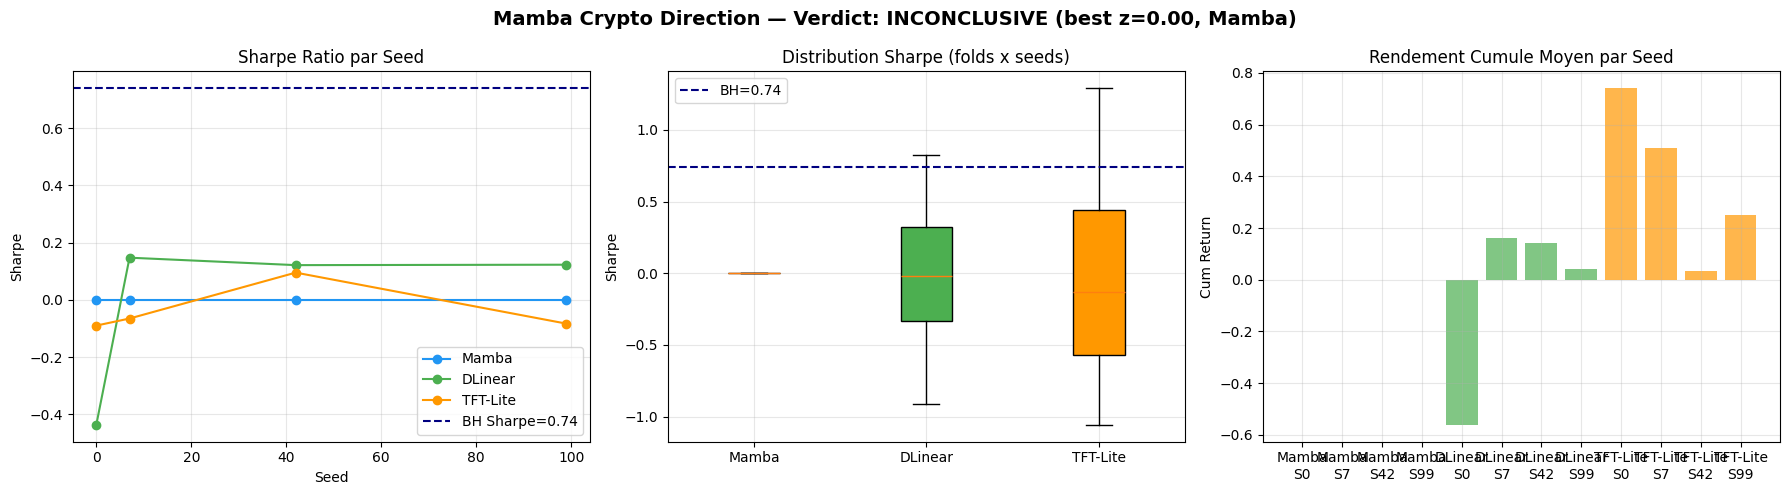


Resume final:
  Mamba: selective SSM (pure PyTorch, d_model=64, d_state=16, 2 layers)
  Baselines: DLinear, TFT-Lite, Buy-and-Hold
  Donnees: ['BTC-USD', 'ETH-USD'] (2018-2024)
  Features: 9 (9 dim)
  Validation: 5-fold WF x 4 seeds
  Transaction costs: 10bps
  Device: cpu (CPU-only)
  VERDICT: INCONCLUSIVE


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_map = {'Mamba': '#2196F3', 'DLinear': '#4CAF50', 'TFT-Lite': '#FF9800'}

# 1. Sharpe par seed et modele
for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_means = model_data.groupby('seed')['sharpe'].mean()
    axes[0].plot(seed_means.index, seed_means.values, 'o-',
                 label=model_name, color=colors_map.get(model_name, 'gray'))
axes[0].axhline(y=bh_sharpe, color='navy', linestyle='--',
                label=f'BH Sharpe={bh_sharpe:.2f}')
axes[0].set_title('Sharpe Ratio par Seed')
axes[0].set_ylabel('Sharpe')
axes[0].set_xlabel('Seed')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Distribution des Sharpes (violin-style)
model_names = list(df_results['model'].unique())
sharpes_by_model = [df_results[df_results['model'] == m]['sharpe'].values
                    for m in model_names]
bp = axes[1].boxplot(sharpes_by_model, labels=model_names, patch_artist=True)
for patch, name in zip(bp['boxes'], model_names):
    patch.set_facecolor(colors_map.get(name, 'lightgray'))
axes[1].axhline(y=bh_sharpe, color='navy', linestyle='--', label=f'BH={bh_sharpe:.2f}')
axes[1].set_title('Distribution Sharpe (folds x seeds)')
axes[1].set_ylabel('Sharpe')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Cumulative returns par seed
for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_cumrets = model_data.groupby('seed')['cum_return'].mean()
    axes[2].bar([f'{model_name}\nS{s}' for s in seed_cumrets.index],
                seed_cumrets.values, alpha=0.7,
                color=colors_map.get(model_name, 'gray'))
axes[2].set_title('Rendement Cumule Moyen par Seed')
axes[2].set_ylabel('Cum Return')
axes[2].grid(True, alpha=0.3)

# Determine global verdict
all_z = []
for model_name, sharpes in model_sharpes.items():
    edges = sharpes - bh_sharpe
    mean_e = np.mean(edges)
    std_e = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
    z = mean_e / std_e if std_e > 1e-10 else 0
    all_z.append((model_name, z))

best_z = max(all_z, key=lambda x: x[1])
global_verdict = 'BEATS' if best_z[1] > 2 else ('NO BEATS' if best_z[1] < -2 else 'INCONCLUSIVE')

plt.suptitle(f'Mamba Crypto Direction — Verdict: {global_verdict} (best z={best_z[1]:.2f}, {best_z[0]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nResume final:')
print(f'  Mamba: selective SSM (pure PyTorch, d_model=64, d_state=16, 2 layers)')
print(f'  Baselines: DLinear, TFT-Lite, Buy-and-Hold')
print(f'  Donnees: {TICKERS} (2018-2024)')
print(f'  Features: {len(feature_cols)} ({INPUT_DIM} dim)')
print(f'  Validation: {N_FOLDS}-fold WF x {len(SEEDS)} seeds')
print(f'  Transaction costs: {TCOST_BPS}bps')
print(f'  Device: {DEVICE} (CPU-only)')
print(f'  VERDICT: {global_verdict}')